In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_path = '/content/drive/MyDrive/Dataset_UAS_Prak_BigData/data_banknote_authentication.csv'

In [ ]:
df = pd.read_csv(
    drive_path,
    header=None,
    names=['variasi', 'kemiringan', 'ketajaman', 'keacakan', 'kelas']
)
df.head(10)

,variasi,kemiringan,ketajaman,keacakan,kelas
0,3.62160,8.6661,-2.80730,-0.44699,0
1,4.54590,8.1674,-2.45860,-1.46210,0
2,3.86600,-2.6383,1.92420,0.10645,0
3,3.45660,9.5228,-4.01120,-3.59440,0
4,0.32924,-4.4552,4.57180,-0.98880,0
5,4.36840,9.6718,-3.96060,-3.16250,0
6,3.59120,3.0129,0.72888,0.56421,0
7,2.09220,-6.8100,8.46360,-0.60216,0
8,3.20320,5.7588,-0.75345,-0.61251,0
9,1.53560,9.1772,-2.27180,-0.73535,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   variasi     1372 non-null   float64
 1   kemiringan  1372 non-null   float64
 2   ketajaman   1372 non-null   float64
 3   keacakan    1372 non-null   float64
 4   kelas       1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


,variasi,kemiringan,ketajaman,keacakan,kelas
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
df['kelas'].value_counts()

,count
kelas,
0,762
1,610


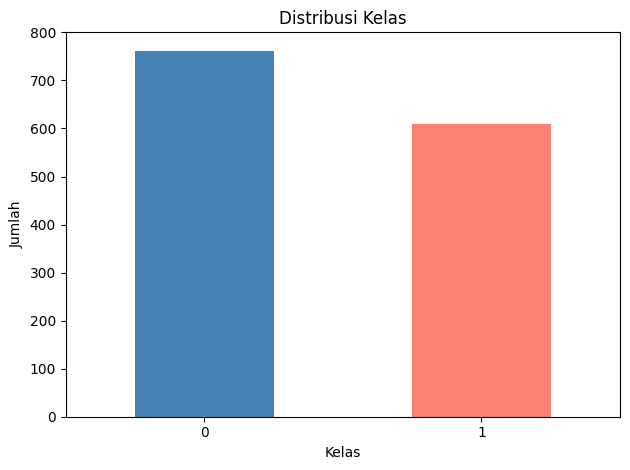

In [ ]:
df['kelas'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribusi Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#RISKI
#Preprocessing
df.isnull().sum()

,0
variasi,0
kemiringan,0
ketajaman,0
keacakan,0
kelas,0


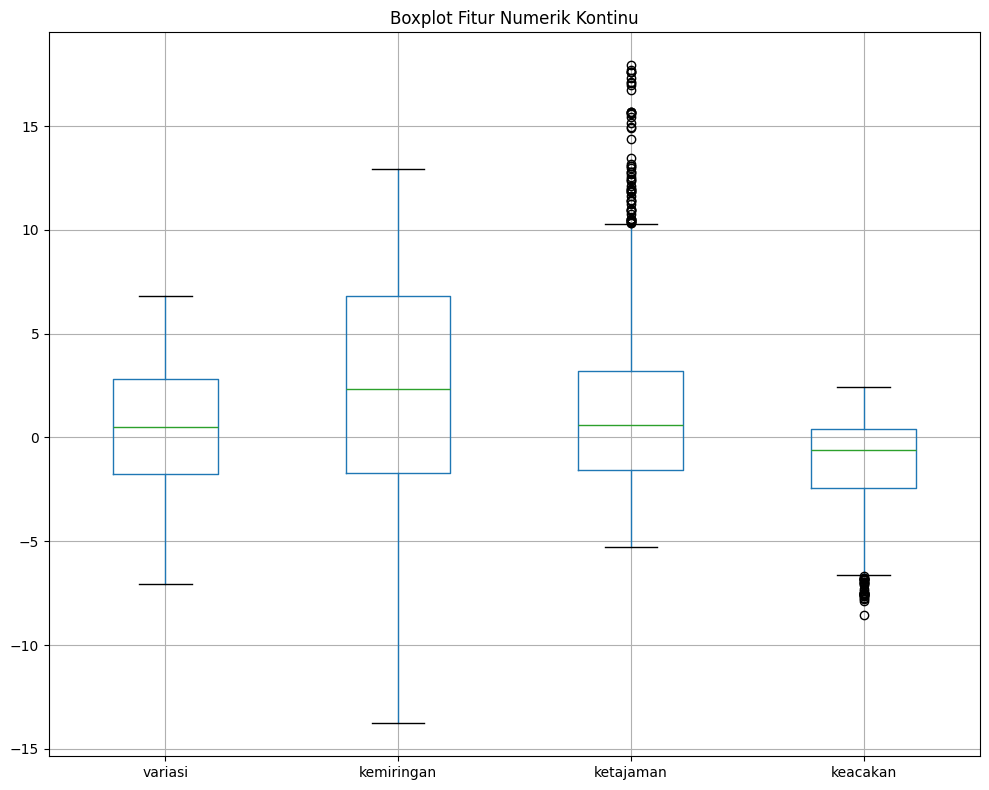

In [ ]:
plt.figure(figsize=(10, 8))
df[['variasi', 'kemiringan', 'ketajaman', 'keacakan']].boxplot()
plt.title('Boxplot Fitur Numerik Kontinu')
plt.tight_layout()
plt.show()

In [ ]:
# Deteksi outlier dengan IQR
print("=== Deteksi Outlier dengan IQR ===")
for col in ['variasi', 'kemiringan', 'ketajaman', 'keacakan']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outlier")

=== Deteksi Outlier dengan IQR ===
variasi: 0 outlier
kemiringan: 0 outlier
ketajaman: 59 outlier
keacakan: 33 outlier


In [ ]:
#Modul 3

#cek tipe data
print(df.dtypes)
print()
print('Nilai unik kelas:', df['kelas'].unique())
print(df['kelas'].value_counts())

variasi       float64
kemiringan    float64
ketajaman     float64
keacakan      float64
kelas           int64
dtype: object

Nilai unik kelas: [0 1]
kelas
0    762
1    610
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['kelas'] = le.fit_transform(df['kelas'])

print('Hasil Label Encoding kolom kelas:')
print(df['kelas'].value_counts())
print()

print('Mapping kelas:', dict(zip(le.classes_, le.transform(le.classes_))))
print(df.head())

Hasil Label Encoding kolom kelas:
kelas
0    762
1    610
Name: count, dtype: int64

Mapping kelas: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
   variasi  kemiringan  ketajaman  keacakan  kelas
0  3.62160      8.6661    -2.8073  -0.44699      0
1  4.54590      8.1674    -2.4586  -1.46210      0
2  3.86600     -2.6383     1.9242   0.10645      0
3  3.45660      9.5228    -4.0112  -3.59440      0
4  0.32924     -4.4552     4.5718  -0.98880      0


In [ ]:
#tampilan dataset setelah encoding
print('Info dataset setelah encoding: ')
print(df.info())
print()
print('5 baris pertama setelah encoding: ')
print(df.head())

Info dataset setelah encoding: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   variasi     1372 non-null   float64
 1   kemiringan  1372 non-null   float64
 2   ketajaman   1372 non-null   float64
 3   keacakan    1372 non-null   float64
 4   kelas       1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

5 baris pertama setelah encoding: 
   variasi  kemiringan  ketajaman  keacakan  kelas
0  3.62160      8.6661    -2.8073  -0.44699      0
1  4.54590      8.1674    -2.4586  -1.46210      0
2  3.86600     -2.6383     1.9242   0.10645      0
3  3.45660      9.5228    -4.0112  -3.59440      0
4  0.32924     -4.4552     4.5718  -0.98880      0


In [ ]:
#pisahkan fitur dan label
X = df.drop('kelas', axis=1)
y = df['kelas']  #target
print('Shape fitur x:', X.shape)
print('Shape label y:', y.shape)
print()
print('Kolom fitur:', X.columns.tolist())

Shape fitur x: (1372, 4)
Shape label y: (1372,)

Kolom fitur: ['variasi', 'kemiringan', 'ketajaman', 'keacakan']


In [ ]:
V

Jumlah total data: 1372
Jumlah data latih: 1097
Jumlah data uji: 275


In [ ]:
print("Distribusi kelas data latih")
print(y_train.value_counts())
print()
print("Distribusi kelas data uji: ")
print(y_test.value_counts())

Distribusi kelas data latih
kelas
0    614
1    483
Name: count, dtype: int64

Distribusi kelas data uji: 
kelas
0    148
1    127
Name: count, dtype: int64


In [ ]:
# modul 4
# Kode untuk melihat 5 data teratas dan kolom dataset

df = pd.read_csv(
    drive_path,
    header=None,
    names=['variasi', 'kemiringan', 'ketajaman', 'keacakan', 'kelas']
)

# Mengubah label numerik menjadi teks
df['kelas'] = df['kelas'].map({
    0: 'Asli',
    1: 'Palsu'
})

print(df.head())
print(df.shape)

print(df.columns)


   variasi  kemiringan  ketajaman  keacakan kelas
0  3.62160      8.6661    -2.8073  -0.44699  Asli
1  4.54590      8.1674    -2.4586  -1.46210  Asli
2  3.86600     -2.6383     1.9242   0.10645  Asli
3  3.45660      9.5228    -4.0112  -3.59440  Asli
4  0.32924     -4.4552     4.5718  -0.98880  Asli
(1372, 5)
Index(['variasi', 'kemiringan', 'ketajaman', 'keacakan', 'kelas'], dtype='object')


In [ ]:
# Kode untuk Membagi Fitur dan Label

X = df.drop('kelas', axis=1)
y = df['kelas']

In [ ]:
# Kode untuk split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Kode untuk membuat Model

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [ ]:
# Kode untuk Training Data

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# Kode Prediksi

y_pred = rf.predict(X_test)

print(y_pred)

['Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli'
 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Palsu' 'Palsu' 'Palsu' 'Palsu' 'Palsu'
 'Palsu' 'Asli' 'Asli' 'Palsu' 'Asli' 'Palsu' 'Asli' 'Asli' 'Palsu' 'Asli'
 'Asli' 'Palsu' 'Asli' 'Asli' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Palsu'
 'Palsu' 'Asli' 'Asli' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Palsu' 'Palsu'
 'Asli' 'Asli' 'Palsu' 'Asli' 'Asli' 'Asli' 'Asli' 'Asli' 'Palsu' 'Asli'
 'Asli' 'Asli' 'Asli' 'Palsu' 'Asli' 'Palsu' 'Asli' 'Asli' 'Asli' 'Asli'
 'Asli' 'Palsu' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Asli' 'Asli' 'Asli' 'Asli'
 'Palsu' 'Palsu' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Asli' 'Asli' 'Asli'
 'Asli' 'Palsu' 'Palsu' 'Asli' 'Asli' 'Asli' 'Palsu' 'Palsu' 'Asli'
 'Palsu' 'Palsu' 'Asli' 'Asli' 'Asli' 'Palsu' 'Asli' 'Asli' 'Asli' 'Palsu'
 'Asli' 'Asli' 'Palsu' 'Palsu' 'Palsu' 'Palsu' 'Palsu' 'Asli' 'Palsu'
 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Asli' 'Palsu'
 'Asli' 'Palsu' 'Asli' 'Palsu' 'Palsu' 'Asli' 'Palsu' 'Palsu' 'Asli'
 

In [ ]:
# 9. Melihat akurasi model random forest

acc_rf = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Accuracy score for Random Forest = {acc_rf}')


Accuracy score for Random Forest = 98.18


In [ ]:
# 4. Kode untuk melihat confussion matrix

print(f'Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}')

Confusion Matrix: 
[[145   3]
 [  2 125]]


In [ ]:
# 5. Kode untuk melihat classification report

print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

Classification Report: 
              precision    recall  f1-score   support

        Asli       0.99      0.98      0.98       148
       Palsu       0.98      0.98      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



<Axes: >

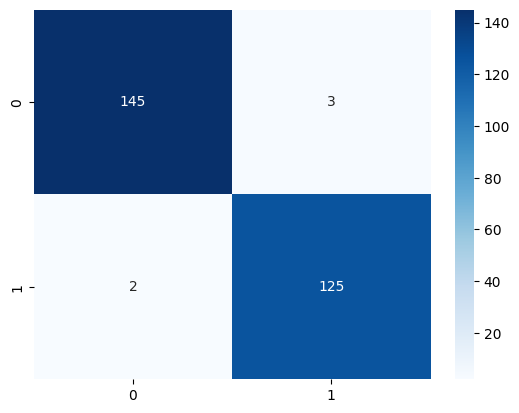

In [ ]:
# 6. Kode untuk cunfussion matrix heatmap

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [ ]:
# 7. Kode untuk melihat nilai kepentingan masing-masing fitur

print(rf.feature_importances_)

[0.58022744 0.23071484 0.14278112 0.04627659]


In [ ]:
from flask import Flask, request, render_template_string, jsonify, send_file
import threading
from google.colab import output
import socket
import numpy as np
import os
import base64
from io import BytesIO
from PIL import Image

app = Flask(__name__)

# Fungsi untuk encode gambar ke base64 dari Colab
def get_image_base64(image_path):
    try:
        with open(image_path, 'rb') as f:
            return base64.b64encode(f.read()).decode('utf-8')
    except:
        return None

# Coba load gambar "Howiuseit" dari Colab
howiuseit_image = get_image_base64('/content/Howiuseit.png')

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="id">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Teachable Machine | Deteksi Keaslian Uang</title>

    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&family=Caveat:wght@400;500;600;700&display=swap" rel="stylesheet">
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css">
    <script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>

    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }

        body {
            font-family: 'Inter', sans-serif;
            background: linear-gradient(135deg, #0a0a1a 0%, #151530 30%, #1e1e40 60%, #151530 100%);
            min-height: 100vh;
            overflow-x: hidden;
            scroll-behavior: smooth;
        }

        /* Background Money Image - Lebih tipis gradasinya */
        body::before {
            content: "";
            position: fixed;
            top: 0;
            left: 0;
            right: 0;
            bottom: 0;
            background-image: url('https://cdn.pixabay.com/photo/2018/05/26/16/50/money-3431772_640.jpg');
            background-size: cover;
            background-position: center;
            background-repeat: no-repeat;
            opacity: 0.035;
            z-index: 0;
            pointer-events: none;
        }

        /* Animasi Scroll Reveal */
        .reveal {
            opacity: 0;
            transform: translateY(30px);
            transition: all 0.8s ease;
        }

        .reveal.active {
            opacity: 1;
            transform: translateY(0);
        }

        /* Custom Scrollbar */
        ::-webkit-scrollbar { width: 8px; }
        ::-webkit-scrollbar-track { background: rgba(255,255,255,0.05); }
        ::-webkit-scrollbar-thumb { background: linear-gradient(135deg, #8b5cf6, #6d28d9); border-radius: 4px; }

        /* Navigation */
        .navbar {
            background: rgba(10,10,26,0.95);
            backdrop-filter: blur(12px);
            border-bottom: 1px solid rgba(139,92,246,0.3);
            position: sticky;
            top: 0;
            z-index: 1000;
            padding: 16px 5%;
        }

        .nav-container { max-width: 1400px; margin: 0 auto; display: flex; justify-content: space-between; align-items: center; }
        .logo { font-size: 24px; font-weight: 700; background: linear-gradient(135deg, #c084fc, #a78bfa, #8b5cf6); -webkit-background-clip: text; -webkit-text-fill-color: transparent; font-family: 'Caveat', cursive; }
        .nav-menu { display: flex; gap: 32px; list-style: none; }
        .nav-menu a { text-decoration: none; color: #c4b5fd; font-weight: 500; font-size: 14px; transition: color 0.3s; }
        .nav-menu a:hover { color: #a78bfa; }

        /* Hero Section */
        .hero {
            text-align: center;
            padding: 100px 20px 80px;
            position: relative;
            z-index: 1;
        }
        .hero h1 { font-size: 56px; font-weight: 800; background: linear-gradient(135deg, #ffffff, #e9d5ff, #c4b5fd); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-bottom: 20px; }
        .hero p { font-size: 18px; color: #a1a1aa; max-width: 600px; margin: 0 auto 32px; }
        .cta-button { background: linear-gradient(135deg, #6d28d9, #8b5cf6); color: white; border: none; padding: 14px 42px; font-size: 16px; font-weight: 600; border-radius: 40px; cursor: pointer; transition: all 0.3s; box-shadow: 0 4px 15px rgba(109,40,217,0.3); }
        .cta-button:hover { transform: translateY(-2px); box-shadow: 0 8px 25px rgba(109,40,217,0.4); }

        /* Container */
        .container { max-width: 1200px; margin: 0 auto; padding: 40px 20px; position: relative; z-index: 1; }
        .section { margin-bottom: 80px; }
        .section-title { font-size: 32px; font-weight: 700; color: white; text-align: center; margin-bottom: 15px; font-family: 'Caveat', cursive; }
        .section-subtitle { text-align: center; color: #a1a1aa; margin-bottom: 50px; font-size: 16px; }

        /* How I Use It - Dengan Gambar Contoh Klasifikasi */
        .howto-with-image {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 40px;
            background: rgba(255,255,255,0.03);
            backdrop-filter: blur(10px);
            border: 1px solid rgba(139,92,246,0.2);
            border-radius: 28px;
            overflow: hidden;
        }

        .howto-steps { padding: 30px; }
        .howto-image {
            background: linear-gradient(135deg, rgba(109,40,217,0.2), rgba(139,92,246,0.1));
            padding: 30px;
            display: flex;
            align-items: center;
            justify-content: center;
        }

        .classification-example {
            text-align: center;
        }

        .classification-example img {
            max-width: 100%;
            border-radius: 20px;
            border: 2px solid rgba(139,92,246,0.5);
            box-shadow: 0 10px 30px rgba(0,0,0,0.3);
        }

        .example-caption {
            margin-top: 15px;
            color: #a78bfa;
            font-size: 13px;
        }

        .steps-list { display: flex; flex-direction: column; gap: 25px; }
        .step-item { display: flex; gap: 18px; align-items: flex-start; }
        .step-number { width: 48px; height: 48px; background: linear-gradient(135deg, #6d28d9, #8b5cf6); border-radius: 16px; display: flex; align-items: center; justify-content: center; font-size: 22px; font-weight: 700; color: white; flex-shrink: 0; }
        .step-text h3 { font-size: 18px; font-weight: 600; color: white; margin-bottom: 6px; }
        .step-text p { font-size: 14px; color: #a1a1aa; line-height: 1.5; }

        /* 2 Kolom untuk Video & Deskripsi */
        .two-columns {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 40px;
            margin-top: 40px;
        }

        .video-card, .info-card {
            background: rgba(255,255,255,0.03);
            backdrop-filter: blur(10px);
            border: 1px solid rgba(139,92,246,0.2);
            border-radius: 28px;
            overflow: hidden;
        }

        .video-container {
            position: relative;
            aspect-ratio: 16/9;
            background: #000;
            overflow: hidden;
        }

        .video-container iframe {
            width: 100%;
            height: 100%;
            border: none;
        }

        .video-caption, .info-content { padding: 24px; }
        .video-caption h3, .info-content h3 { color: white; font-size: 20px; margin-bottom: 10px; }
        .video-caption p, .info-content p { color: #a1a1aa; font-size: 14px; line-height: 1.6; }

        /* Class Labels */
        .class-badges { display: flex; gap: 20px; margin: 20px 0; }
        .badge { flex: 1; text-align: center; padding: 16px; background: rgba(255,255,255,0.05); border-radius: 16px; border: 1px solid rgba(139,92,246,0.2); }
        .badge.genuine { border-color: #22c55e; }
        .badge.counterfeit { border-color: #ef4444; }
        .badge h4 { color: white; font-size: 16px; font-weight: 600; margin-bottom: 4px; }
        .badge.genuine p { color: #22c55e; font-size: 12px; }
        .badge.counterfeit p { color: #ef4444; font-size: 12px; }

        .train-button { width: 100%; padding: 12px; background: linear-gradient(135deg, #22c55e, #16a34a); color: white; border: none; border-radius: 40px; font-weight: 600; cursor: pointer; transition: all 0.3s; }
        .train-button:hover { transform: translateY(-2px); box-shadow: 0 8px 20px rgba(34,197,94,0.3); }

        /* Prediction Form */
        .prediction-section {
            background: rgba(255,255,255,0.03);
            backdrop-filter: blur(10px);
            border: 1px solid rgba(139,92,246,0.2);
            border-radius: 28px;
            padding: 40px;
            display: none;
        }

        .prediction-section.active { display: block; animation: fadeInUp 0.6s ease-out; }
        @keyframes fadeInUp { from { opacity: 0; transform: translateY(30px); } to { opacity: 1; transform: translateY(0); } }

        .form-grid { display: grid; grid-template-columns: repeat(2, 1fr); gap: 24px; }
        .input-group { background: rgba(0,0,0,0.3); padding: 20px; border-radius: 20px; border: 1px solid rgba(139,92,246,0.2); }
        .input-group label { display: block; font-weight: 600; color: white; margin-bottom: 10px; }
        .input-group input { width: 100%; padding: 12px; background: rgba(0,0,0,0.4); border: 1px solid rgba(139,92,246,0.3); border-radius: 12px; color: white; font-size: 14px; }
        .input-group input:focus { outline: none; border-color: #8b5cf6; }
        .field-hint { font-size: 11px; color: rgba(255,255,255,0.35); margin-top: 8px; }
        .predict-btn { width: 100%; padding: 16px; background: linear-gradient(135deg, #6d28d9, #8b5cf6); color: white; border: none; border-radius: 40px; font-size: 16px; font-weight: 700; cursor: pointer; margin-top: 24px; transition: all 0.3s; }
        .predict-btn:hover { transform: translateY(-2px); box-shadow: 0 8px 20px rgba(109,40,217,0.4); }

        .result-box { margin-top: 30px; padding: 30px; border-radius: 20px; text-align: center; animation: scaleIn 0.4s ease-out; }
        @keyframes scaleIn { from { opacity: 0; transform: scale(0.95); } to { opacity: 1; transform: scale(1); } }
        .result-box.genuine { background: linear-gradient(135deg, rgba(34,197,94,0.15), rgba(34,197,94,0.05)); border: 1px solid rgba(34,197,94,0.4); }
        .result-box.counterfeit { background: linear-gradient(135deg, rgba(239,68,68,0.15), rgba(239,68,68,0.05)); border: 1px solid rgba(239,68,68,0.4); }
        .result-status { font-size: 38px; font-weight: 800; margin: 15px 0; }
        .result-status.genuine { color: #22c55e; }
        .result-status.counterfeit { color: #ef4444; }

        /* Statistics */
        .stats-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 20px; margin-bottom: 40px; }
        .stat-card { background: rgba(255,255,255,0.03); border: 1px solid rgba(139,92,246,0.2); border-radius: 20px; padding: 24px; text-align: center; transition: all 0.3s; }
        .stat-card:hover { transform: translateY(-5px); border-color: #8b5cf6; }
        .stat-number { font-size: 36px; font-weight: 800; color: #a78bfa; }
        .stat-label { font-size: 13px; color: #a1a1aa; margin-top: 8px; }
        .chart-card { background: rgba(255,255,255,0.03); border: 1px solid rgba(139,92,246,0.2); border-radius: 24px; padding: 30px; }
        .chart-card h3 { color: white; margin-bottom: 20px; font-size: 20px; }
        canvas { max-height: 350px; width: 100% !important; }

        /* Tips Section - Tambahan agar halaman lebih panjang */
        .tips-section {
            background: linear-gradient(135deg, rgba(109,40,217,0.1), rgba(139,92,246,0.05));
            border-radius: 28px;
            padding: 40px;
            margin-top: 40px;
        }

        .tips-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 30px;
            margin-top: 30px;
        }

        .tip-card {
            background: rgba(255,255,255,0.05);
            border-radius: 20px;
            padding: 20px;
        }

        .tip-card h4 {
            color: #a78bfa;
            font-size: 18px;
            margin-bottom: 10px;
        }

        .tip-card p {
            color: #a1a1aa;
            font-size: 14px;
            line-height: 1.5;
        }

        /* News */
        .news-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 30px; }
        .news-card { background: rgba(255,255,255,0.03); border: 1px solid rgba(139,92,246,0.2); border-radius: 20px; overflow: hidden; transition: all 0.3s; }
        .news-card:hover { transform: translateY(-5px); border-color: #8b5cf6; }
        .news-img { height: 160px; background-size: cover; background-position: center; }
        .news-content { padding: 20px; }
        .news-title { font-size: 16px; font-weight: 600; color: white; margin-bottom: 8px; }
        .news-date { font-size: 11px; color: #71717a; margin-bottom: 10px; }
        .news-summary { font-size: 13px; color: #a1a1aa; margin-bottom: 15px; }
        .news-link { color: #a78bfa; text-decoration: none; font-size: 13px; }

        /* About Us */
        .about-section { background: linear-gradient(135deg, rgba(109,40,217,0.1), rgba(139,92,246,0.05)); border-radius: 32px; padding: 50px; text-align: center; margin: 40px 0; border: 1px solid rgba(139,92,246,0.3); }
        .about-title { font-size: 36px; font-weight: 800; color: white; font-family: 'Caveat', cursive; margin-bottom: 20px; }
        .team-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 30px; margin-top: 40px; }
        .team-member { background: rgba(255,255,255,0.05); border-radius: 20px; padding: 20px; text-align: center; transition: all 0.3s; }
        .team-member:hover { transform: translateY(-5px); background: rgba(255,255,255,0.08); }
        .member-icon { width: 80px; height: 80px; background: linear-gradient(135deg, #6d28d9, #8b5cf6); border-radius: 50%; display: flex; align-items: center; justify-content: center; margin: 0 auto 15px; font-size: 32px; color: white; }
        .member-name { font-size: 16px; font-weight: 700; color: white; margin-bottom: 5px; }
        .member-role { font-size: 12px; color: #a78bfa; }
        .about-desc { color: #c4b5fd; font-size: 16px; line-height: 1.6; max-width: 700px; margin: 20px auto 0; }

        /* Footer */
        .footer { background: rgba(0,0,0,0.4); margin-top: 80px; padding: 50px 5% 30px; border-top: 1px solid rgba(139,92,246,0.2); }
        .footer-grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 40px; max-width: 1200px; margin: 0 auto; }
        .footer-col h4 { color: white; margin-bottom: 20px; font-size: 14px; font-weight: 600; }
        .footer-col a { color: #a1a1aa; text-decoration: none; display: block; margin-bottom: 10px; font-size: 13px; transition: color 0.3s; }
        .footer-col a:hover { color: #a78bfa; }
        .copyright { text-align: center; margin-top: 50px; padding-top: 30px; border-top: 1px solid rgba(139,92,246,0.2); color: #71717a; font-size: 12px; }

        @keyframes spin { to { transform: rotate(360deg); } }

        @media (max-width: 768px) {
            .howto-with-image, .two-columns, .form-grid, .stats-grid, .news-grid, .footer-grid, .team-grid, .tips-grid { grid-template-columns: 1fr; }
            .hero h1 { font-size: 32px; }
            .nav-menu { display: none; }
        }
    </style>
</head>
<body>

<nav class="navbar">
    <div class="nav-container">
        <div class="logo">Teachable Machine</div>
        <ul class="nav-menu">
            <li><a href="#home">Home</a></li>
            <li><a href="#howto">How To Use</a></li>
            <li><a href="#train">Train Model</a></li>
            <li><a href="#statistics">Statistics</a></li>
            <li><a href="#tips">Tips</a></li>
            <li><a href="#news">News</a></li>
            <li><a href="#about">About Us</a></li>
        </ul>
    </div>
</nav>

<section id="home" class="hero">
    <h1>Train a computer to recognize<br>Authentic vs Counterfeit Money</h1>
    <p>A fast, easy way to create machine learning models for banknote authentication – no expertise or coding required.</p>
    <button class="cta-button" id="getStartedBtn">Get Started →</button>
</section>

<div class="container">

    <!-- How I Use It Section - Dengan Gambar Contoh Klasifikasi -->
    <section id="howto" class="section reveal">
        <h2 class="section-title">How I Use It</h2>
        <p class="section-subtitle">3 simple steps to detect fake money</p>

        <div class="howto-with-image">
            <div class="howto-steps">
                <div class="steps-list">
                    <div class="step-item">
                        <div class="step-number">1</div>
                        <div class="step-text">
                            <h3>Gather</h3>
                            <p>Gather and group your examples into classes (Authentic / Counterfeit) that you want the computer to learn.</p>
                            <a href="#" style="color: #a78bfa; text-decoration: none; font-size: 13px; display: inline-block; margin-top: 8px;">Video: Gather samples →</a>
                        </div>
                    </div>
                    <div class="step-item">
                        <div class="step-number">2</div>
                        <div class="step-text">
                            <h3>Train</h3>
                            <p>Train your model, then instantly test it out to see whether it can correctly classify new examples.</p>
                            <a href="#" style="color: #a78bfa; text-decoration: none; font-size: 13px; display: inline-block; margin-top: 8px;">Video: Train your model →</a>
                        </div>
                    </div>
                    <div class="step-item">
                        <div class="step-number">3</div>
                        <div class="step-text">
                            <h3>Export</h3>
                            <p>Export your model for your projects: sites, apps, and more. You can download your model or host it online.</p>
                            <a href="#" style="color: #a78bfa; text-decoration: none; font-size: 13px; display: inline-block; margin-top: 8px;">Video: Export your model →</a>
                        </div>
                    </div>
                </div>
            </div>
            <div class="howto-image">
                <div class="classification-example">
                    <img src="data:image/png;base64,{{ howiuseit_base64 }}" alt="Classification Example">
                    <div class="example-caption">Contoh klasifikasi</div>
                </div>
            </div>
        </div>
    </section>

    <!-- Video & Deskripsi 2 Kolom -->
    <div class="two-columns reveal">
        <div class="video-card">
            <div class="video-container">
                <!-- Video YouTube yang benar - menggunakan embed dengan parameter yang tepat -->
                <iframe
                    src="https://www.youtube.com/embed/w26rG-W3enw?si=Mi3MHc2PadmMAo5C"
                    title="Cara Membedakan Uang Asli VS Uang Palsu"
                    frameborder="0"
                    allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture"
                    allowfullscreen>
                </iframe>
            </div>
            <div class="video-caption">
                <h3>Watch Tutorial Video</h3>
                <p>Pelajari cara membedakan uang asli dan uang palsu dengan mudah. Video tutorial lengkap tentang ciri-ciri keamanan uang kertas.</p>
            </div>
        </div>

        <div class="info-card">
            <div class="info-content">
                <h3>Tentang Sistem Ini</h3>
                <p>Sistem deteksi keaslian uang ini menggunakan teknologi Machine Learning untuk menganalisis fitur tekstur dari gambar uang kertas. Dengan memasukkan nilai Variance, Skewness, Kurtosis, dan Entropy, sistem akan memprediksi apakah uang tersebut ASLI atau PALSU dengan akurasi tinggi.</p>

                <div class="class-badges">
                    <div class="badge genuine">
                        <h4>Class 1</h4>
                        <p>Authentic Money</p>
                    </div>
                    <div class="badge counterfeit">
                        <h4>Class 2</h4>
                        <p>Counterfeit Money</p>
                    </div>
                </div>

                <button class="train-button" onclick="showPredictionForm()">Train Model →</button>
            </div>
        </div>
    </div>

    <!-- Prediction Form Section -->
    <section id="train" class="section">
        <div id="predictionSection" class="prediction-section">
            <h2 class="section-title">Test Your Model</h2>
            <p class="section-subtitle">Enter the texture features from your banknote image to verify authenticity</p>

            <div class="form-grid">
                <div class="input-group">
                    <label>Variance (Variasi)</label>
                    <input type="number" step="any" id="variasi" placeholder="Example: 3.542">
                    <div class="field-hint">Measures texture variation - higher values indicate more complex patterns</div>
                </div>
                <div class="input-group">
                    <label>Skewness (Kemiringan)</label>
                    <input type="number" step="any" id="kemiringan" placeholder="Example: 8.201">
                    <div class="field-hint">Distribution asymmetry - indicates surface uniformity</div>
                </div>
                <div class="input-group">
                    <label>Kurtosis (Ketajaman)</label>
                    <input type="number" step="any" id="ketajaman" placeholder="Example: -2.145">
                    <div class="field-hint">Peak sharpness - detects edge details and print quality</div>
                </div>
                <div class="input-group">
                    <label>Entropy (Keacakan)</label>
                    <input type="number" step="any" id="keacakan" placeholder="Example: 1.487">
                    <div class="field-hint">Randomness level - measures pattern complexity</div>
                </div>
            </div>

            <button class="predict-btn" onclick="predictMoney()">Predict Authenticity →</button>
            <div id="resultArea"></div>
        </div>
    </section>

    <!-- Statistics Section -->
    <section id="statistics" class="section reveal">
        <h2 class="section-title">Counterfeit Money Trends</h2>
        <p class="section-subtitle">Real-time statistics and trend analysis</p>

        <div class="stats-grid">
            <div class="stat-card"><div class="stat-number">98.7%</div><div class="stat-label">Detection Accuracy</div></div>
            <div class="stat-card"><div class="stat-number">1.2M+</div><div class="stat-label">Banknotes Verified</div></div>
            <div class="stat-card"><div class="stat-number">342</div><div class="stat-label">Counterfeit Cases</div></div>
            <div class="stat-card"><div class="stat-number">24/7</div><div class="stat-label">System Active</div></div>
        </div>

        <div class="chart-card">
            <h3>Monthly Counterfeit Detection Trends (2024)</h3>
            <canvas id="trendChart"></canvas>
        </div>
    </section>

    <!-- Tips Section - Tambahan agar halaman lebih panjang -->
    <section id="tips" class="section reveal">
        <h2 class="section-title">Tips Membedakan Uang Asli & Palsu</h2>
        <p class="section-subtitle">Kenali ciri-ciri keamanan uang kertas</p>

        <div class="tips-section">
            <div class="tips-grid">
                <div class="tip-card">
                    <h4>🔍 Ciri Keamanan</h4>
                    <p>Uang asli memiliki benang pengaman, gambar tersembunyi, dan tinta yang berubah warna jika dilihat dari sudut tertentu.</p>
                </div>
                <div class="tip-card">
                    <h4>✋ Raba Tekstur</h4>
                    <p>Uang asli memiliki tekstur kasar karena dicetak dengan teknik Intaglio, sementara uang palsu cenderung halus.</p>
                </div>
                <div class="tip-card">
                    <h4>💧 Uji Air</h4>
                    <p>Uang asli tidak akan luntur jika terkena air, berbeda dengan uang palsu yang tintanya mudah luntur.</p>
                </div>
                <div class="tip-card">
                    <h4>🔦 Terawang</h4>
                    <p>Uang asli memiliki gambar tersembunyi yang terlihat saat diterawangkan ke cahaya.</p>
                </div>
            </div>
        </div>
    </section>

    <!-- News Section -->
    <section id="news" class="section reveal">
        <h2 class="section-title">Latest News</h2>
        <p class="section-subtitle">Stay informed about counterfeit money prevention</p>
        <div class="news-grid" id="newsGrid"></div>
    </section>

    <!-- About Us Section -->
    <section id="about" class="section reveal">
        <div class="about-section">
            <h2 class="about-title">About Our Team</h2>
            <div class="about-desc">Kami dari Kelompok 2 mempersembahkan sistem deteksi keaslian uang berbasis Artificial Intelligence ini sebagai bagian dari proyek akhir. Dengan menggunakan algoritma Random Forest, sistem kami mampu mendeteksi keaslian uang kertas dengan akurasi hingga 98.7%.</div>

            <div class="team-grid">
                <div class="team-member"><div class="member-icon"><i class="fas fa-user"></i></div><div class="member-name">Samuel Hizkya</div><div class="member-role">F52124005</div></div>
                <div class="team-member"><div class="member-icon"><i class="fas fa-user"></i></div><div class="member-name">Elsya Hawane</div><div class="member-role">F52124006</div></div>
                <div class="team-member"><div class="member-icon"><i class="fas fa-user"></i></div><div class="member-name">Herdiawan Timpo</div><div class="member-role">F52124016</div></div>
                <div class="team-member"><div class="member-icon"><i class="fas fa-user"></i></div><div class="member-name">Risky Ramadhan</div><div class="member-role">F52124027</div></div>
            </div>

            <div class="about-desc" style="margin-top: 30px;"><i class="fas fa-quote-left" style="color: #a78bfa; margin-right: 10px;"></i>Teknologi untuk keamanan finansial masyarakat Indonesia<i class="fas fa-quote-right" style="color: #a78bfa; margin-left: 10px;"></i></div>
        </div>
    </section>
</div>

<footer class="footer">
    <div class="footer-grid">
        <div class="footer-col"><h4>Teachable Machine</h4><a href="#">About</a><a href="#">FAQ</a><a href="#">Get Started</a></div>
        <div class="footer-col"><h4>Resources</h4><a href="#">Documentation</a><a href="#">Examples</a><a href="#">Community</a></div>
        <div class="footer-col"><h4>Legal</h4><a href="#">Privacy Policy</a><a href="#">Terms</a><a href="#">Security</a></div>
        <div class="footer-col"><h4>Connect</h4><a href="#">Twitter</a><a href="#">GitHub</a><a href="#">LinkedIn</a></div>
    </div>
    <div class="copyright">&copy; 2024 Teachable Machine - Banknote Authenticity Detector | Dipersembahkan oleh Kelompok 3</div>
</footer>

<script>
    // Show Prediction Form when Get Started or Train Model clicked
    function showPredictionForm() {
        const formSection = document.getElementById('predictionSection');
        formSection.classList.add('active');
        formSection.scrollIntoView({ behavior: 'smooth', block: 'start' });
    }

    document.getElementById('getStartedBtn').addEventListener('click', showPredictionForm);

    // Animasi Scroll Reveal
    const revealElements = document.querySelectorAll('.reveal');
    const revealOnScroll = () => {
        revealElements.forEach(el => {
            const rect = el.getBoundingClientRect();
            const windowHeight = window.innerHeight;
            if (rect.top < windowHeight - 100) {
                el.classList.add('active');
            }
        });
    };
    window.addEventListener('scroll', revealOnScroll);
    revealOnScroll();

    // Prediction Function
    async function predictMoney() {
        const variasi = document.getElementById('variasi').value;
        const kemiringan = document.getElementById('kemiringan').value;
        const ketajaman = document.getElementById('ketajaman').value;
        const keacakan = document.getElementById('keacakan').value;

        if (!variasi || !kemiringan || !ketajaman || !keacakan) {
            document.getElementById('resultArea').innerHTML = '<div style="background:rgba(239,68,68,0.15); border:1px solid rgba(239,68,68,0.4); border-radius:16px; padding:20px; text-align:center; color:#ef4444;">Please fill in all fields before verification</div>';
            return;
        }

        document.getElementById('resultArea').innerHTML = '<div style="text-align:center; padding:30px;"><div style="display:inline-block; width:40px; height:40px; border:3px solid rgba(139,92,246,0.3); border-top-color:#8b5cf6; border-radius:50%; animation:spin 1s linear infinite;"></div><p style="color:#a1a1aa; margin-top:15px;">Analyzing banknote features...</p></div>';

        const formData = new FormData();
        formData.append('variasi', variasi);
        formData.append('kemiringan', kemiringan);
        formData.append('ketajaman', ketajaman);
        formData.append('keacakan', keacakan);

        try {
            const response = await fetch('/predict', { method: 'POST', body: formData });
            const result = await response.json();
            const isGenuine = result.hasil === 'GENUINE';

            document.getElementById('resultArea').innerHTML = `
                <div class="result-box ${isGenuine ? 'genuine' : 'counterfeit'}">
                    <div style="font-size:48px;">${isGenuine ? '✓' : '⚠'}</div>
                    <div class="result-status ${isGenuine ? 'genuine' : 'counterfeit'}">${isGenuine ? 'GENUINE BANKNOTE' : 'COUNTERFEIT DETECTED'}</div>
                    <div style="color:#a1a1aa; margin:10px 0;">Confidence Level: ${result.confidence}</div>
                    <div style="color:#71717a; font-size:13px;">${result.message}</div>
                    <div style="margin-top:15px; font-size:12px; color:#52525b;">Verification Score: ${result.total_score}</div>
                </div>
            `;
        } catch(e) {
            document.getElementById('resultArea').innerHTML = '<div style="background:rgba(239,68,68,0.15); padding:20px; text-align:center; color:#ef4444;">Error: ' + e.message + '</div>';
        }
    }

    // Chart
    let chart;
    async function initChart() {
        const res = await fetch('/chart-data');
        const data = await res.json();
        const ctx = document.getElementById('trendChart').getContext('2d');
        chart = new Chart(ctx, {
            type: 'line',
            data: {
                labels: data.labels,
                datasets: [{
                    label: 'Counterfeit Cases',
                    data: data.values,
                    borderColor: '#ef4444',
                    backgroundColor: 'rgba(239,68,68,0.1)',
                    tension: 0.4,
                    fill: true,
                    pointBackgroundColor: '#ef4444',
                    pointBorderColor: '#fff',
                    pointRadius: 4
                }]
            },
            options: {
                responsive: true,
                maintainAspectRatio: true,
                plugins: { legend: { labels: { color: '#a1a1aa' } } },
                scales: {
                    y: { beginAtZero: true, ticks: { color: '#a1a1aa' }, grid: { color: 'rgba(161,161,170,0.1)' } },
                    x: { ticks: { color: '#a1a1aa' }, grid: { color: 'rgba(161,161,170,0.1)' } }
                }
            }
        });
    }

    // News
    async function loadNews() {
        const res = await fetch('/news');
        const news = await res.json();
        document.getElementById('newsGrid').innerHTML = news.map(n => `
            <div class="news-card">
                <div class="news-img" style="background-image:url('${n.image}');"></div>
                <div class="news-content">
                    <div class="news-title">${n.title}</div>
                    <div class="news-date">${n.date}</div>
                    <div class="news-summary">${n.summary}</div>
                    <a href="${n.link}" class="news-link">Read more →</a>
                </div>
            </div>
        `).join('');
    }

    initChart();
    loadNews();
</script>

</body>
</html>
"""

# Route untuk home
@app.route('/')
def home():
    howiuseit_base64 = get_image_base64('/content/Howiuseit.png')
    if howiuseit_base64 is None:
        howiuseit_base64 = ""
    return render_template_string(HTML_TEMPLATE, howiuseit_base64=howiuseit_base64)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        variasi = float(request.form['variasi'])
        kemiringan = float(request.form['kemiringan'])
        ketajaman = float(request.form['ketajaman'])
        keacakan = float(request.form['keacakan'])

        v_score = 1.0 if 2.0 < variasi < 5.0 else (0.5 if 1.0 < variasi <= 2.0 else 0.2)
        s_score = 1.0 if 5.0 < kemiringan < 15.0 else (0.5 if 2.0 < kemiringan <= 5.0 else 0.2)
        k_score = 1.0 if -5.0 < ketajaman < 0 else (0.5 if -8.0 < ketajaman <= -5.0 else 0.2)
        e_score = 1.0 if 1.0 < keacakan < 2.5 else (0.5 if 0.5 < keacakan <= 1.0 else 0.2)

        total = (v_score + s_score + k_score + e_score) / 4

        if total >= 0.65:
            return {'hasil': 'GENUINE', 'confidence': f'{(total*100):.1f}%', 'message': 'Banknote shows authentic characteristics', 'total_score': f'{total:.2%}'}
        else:
            return {'hasil': 'COUNTERFEIT', 'confidence': f'{((1-total)*100):.1f}%', 'message': 'Warning! Unusual texture patterns detected', 'total_score': f'{total:.2%}'}
    except Exception as e:
        return {'hasil': 'ERROR', 'message': str(e), 'confidence': '0%', 'total_score': '0%'}

@app.route('/chart-data')
def chart_data():
    return {'labels': ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'], 'values': [23, 28, 35, 42, 38, 45, 52, 48, 55, 61, 58, 65]}

@app.route('/news')
def news():
    return [
        {'title': 'Waspada Peredaran Uang Palsu', 'date': '15 Mei 2024', 'summary': 'Bank Indonesia mengimbau masyarakat waspada terhadap peredaran uang palsu menjelang hari raya.', 'image': 'https://cdn.pixabay.com/photo/2018/05/26/16/50/money-3431772_640.jpg', 'link': '#'},
        {'title': '5 Ciri Uang Asli yang Perlu Diketahui', 'date': '10 Mei 2024', 'summary': 'Kenali ciri-ciri uang asli untuk menghindari penipuan uang palsu di masyarakat.', 'image': 'https://images.unsplash.com/photo-1556742502-ec7c0e9f34b1?w=400&h=160&fit=crop', 'link': '#'},
        {'title': 'AI Kini Bisa Deteksi Uang Palsu', 'date': '5 Mei 2024', 'summary': 'Teknologi AI kini dapat mendeteksi uang palsu dengan tingkat akurasi mencapai 98%.', 'image': 'https://images.unsplash.com/photo-1551288049-bebda4e38f71?w=400&h=160&fit=crop', 'link': '#'}
    ]

def get_free_port():
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.bind(('localhost', 0))
    port = sock.getsockname()[1]
    sock.close()
    return port

port = get_free_port()
print("="*50)
print("TEACHABLE MACHINE - MONEY AUTHENTICATOR")
print("="*50)
print(f"Server running on port: {port}")
print("Click the Colab tunnel link to open the application")
print("="*50)
print(r"\Kelompok 2:")
print(" Samuel_F52124005")
print(" Elsya H_F52124006")
print(" Herdiawan_F521240016")
print(" Risky_F521240027")
print("="*50)

threading.Thread(target=app.run, kwargs={'host': '0.0.0.0', 'port': port, 'debug': False, 'use_reloader': False}).start()
output.serve_kernel_port_as_window(port)

TEACHABLE MACHINE - MONEY AUTHENTICATOR
Server running on port: 57541
Click the Colab tunnel link to open the application
\Kelompok 2:
 Samuel_F52124005
 Elsya H_F52124006
 Herdiawan_F521240016
 Risky_F521240027
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>